# OSM API Python

Trying out this example (https://pygis.io/docs/d_access_osm.html) to get querying OSM given a polygon.

In [1]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
import time
import pandas as pd
from tqdm import tqdm

place_name = "Dublin, Ireland"

# get place boundary related to the place name as a gdf
area = ox.geocode_to_gdf(place_name)
print(area.geometry)

0    POLYGON ((-6.38703 53.34081, -6.38658 53.33867...
Name: geometry, dtype: geometry


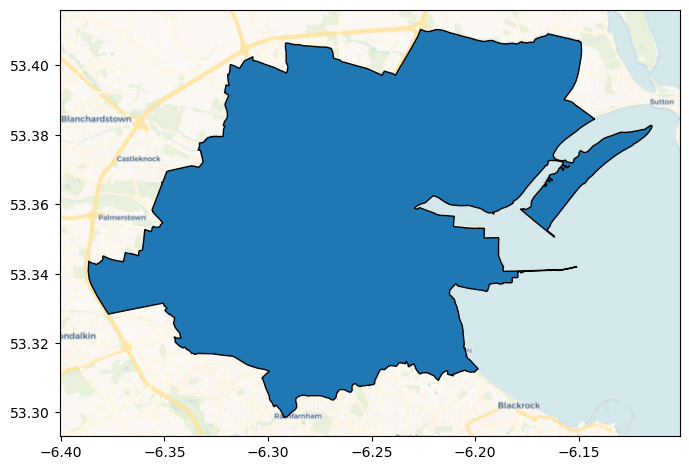

In [2]:
fig, ax = plt.subplots(1,1,figsize=(8,10))


area.plot(ax=ax, edgecolor='black')
cx.add_basemap(ax, crs='EPSG:4326', attribution=False, source=cx.providers.CartoDB.Voyager)

plt.show()

In [ ]:
#tags = {'amenity' : True}

#ameneties = ox.features_from_place(place_name, tags)

#ameneties.to_file("dcc_ameneties.geojson")

ameneties = gpd.read_file("dcc_ameneties.geojson")

,element,id,addr:city,addr:street,amenity,brand,brand:wikidata,brand:wikipedia,name,old_brand,...,opening_date,recycling:textiles,portable,motor_vehicle,lockable,water,building:levels:underground,stands,drawbar_slot,geometry
0,node,28851055,Dublin,North Road,fuel,Circle K,Q3268010,en:Circle K,Circle K,Topaz,...,None,None,None,None,None,None,None,None,None,POINT (-6.30699 53.39947)
1,node,111887569,None,None,parking,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (-6.24209 53.34876)
2,node,111929646,None,None,parking,None,None,None,IFSC Car Park,None,...,None,None,None,None,None,None,None,None,None,POINT (-6.24619 53.34859)
3,node,130156802,Dublin,Store Street,pub,None,None,None,Le Monde Café Bar,None,...,None,None,None,None,None,None,None,None,None,POINT (-6.25276 53.35019)
4,node,130826074,None,None,vending_machine,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,POINT (-6.24588 53.33754)


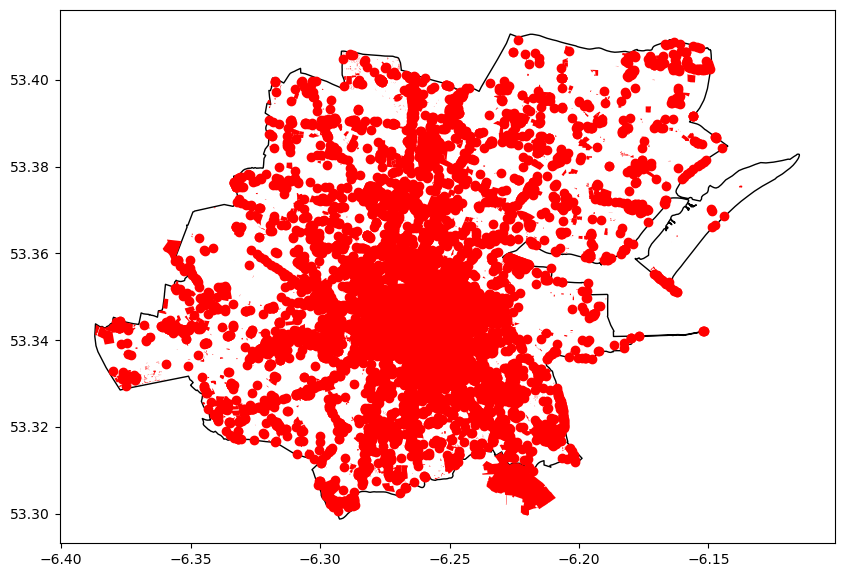

In [4]:
fig, ax = plt.subplots(1,1, figsize=(10,8))

area.plot(ax=ax, edgecolor='black', facecolor='none')
ameneties.plot(ax=ax, color='red')
plt.show()

In [7]:
import numpy as np
import ndtest
import random

for num_points in range(100, 15000, 100):
    # generate mock samples for the test
    seed = random.randint(0,1000000)
    np.random.seed(seed)
    amenity_points = ameneties.geometry[ameneties.geometry.geom_type=='Point'].sample(num_points).reset_index(drop=True)

    # Generate a Gaussian distribution within the bounds of the region
    min_x, min_y, max_x, max_y = area.total_bounds
    cx, cy = area.centroid.x[0], area.centroid.y[0]
    sd_x = (max_y - min_y)/8
    sd_y = (max_x - min_x)/8
    cov = np.array([[sd_y**2, 0], [0, sd_x**2]])
    pts = pd.DataFrame(np.random.multivariate_normal((cx, cy), cov, size=int(round(num_points*4))), columns=['x','y'])
    geo_pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(pts['x'], pts['y'], crs=4326))
    geo_pts = geo_pts.sjoin(area, predicate='within')
    if num_points < len(geo_pts):
        geo_pts = geo_pts.sample(num_points).reset_index(drop=True)


    pts1 = pd.DataFrame(np.random.multivariate_normal((cx, cy), cov, size=int(round(num_points*4))), columns=['x','y'])
    pts2 = pd.DataFrame(np.random.multivariate_normal((cx, cy), cov, size=int(round(num_points*4))), columns=['x','y'])
    x1, y1 = amenity_points.x, amenity_points.y
    x2, y2 = geo_pts.geometry.x, geo_pts.geometry.y


    # 2D KS
    P, D = ndtest.ks2d2s(x1, y1, x2, y2, extra=True)
    print(f"{P=:.3g}, {D=:.3g}")
    if D < 0.2:
        print("##### Better fit found #####")
        fig, ax = plt.subplots(1,2, figsize=(10,8))
        geo_pts.geometry.plot(ax=ax[0], color='blue')
        ax[0].set_title("Gaussian Points")
        amenity_points.plot(ax=ax[1], color='green')
        ax[1].set_title("OSM Amentiies")
        plt.show()
        break
    



/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]
/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]


P=6.87e-06, D=0.405
P=8.21e-09, D=0.365


/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]


P=1.26e-10, D=0.332


/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]


...

P=1.2e-111, D=0.365


/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]


P=7.36e-115, D=0.364


/tmp/ipykernel_47852/665399192.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx, cy = area.centroid.x[0], area.centroid.y[0]


KeyboardInterrupt: 

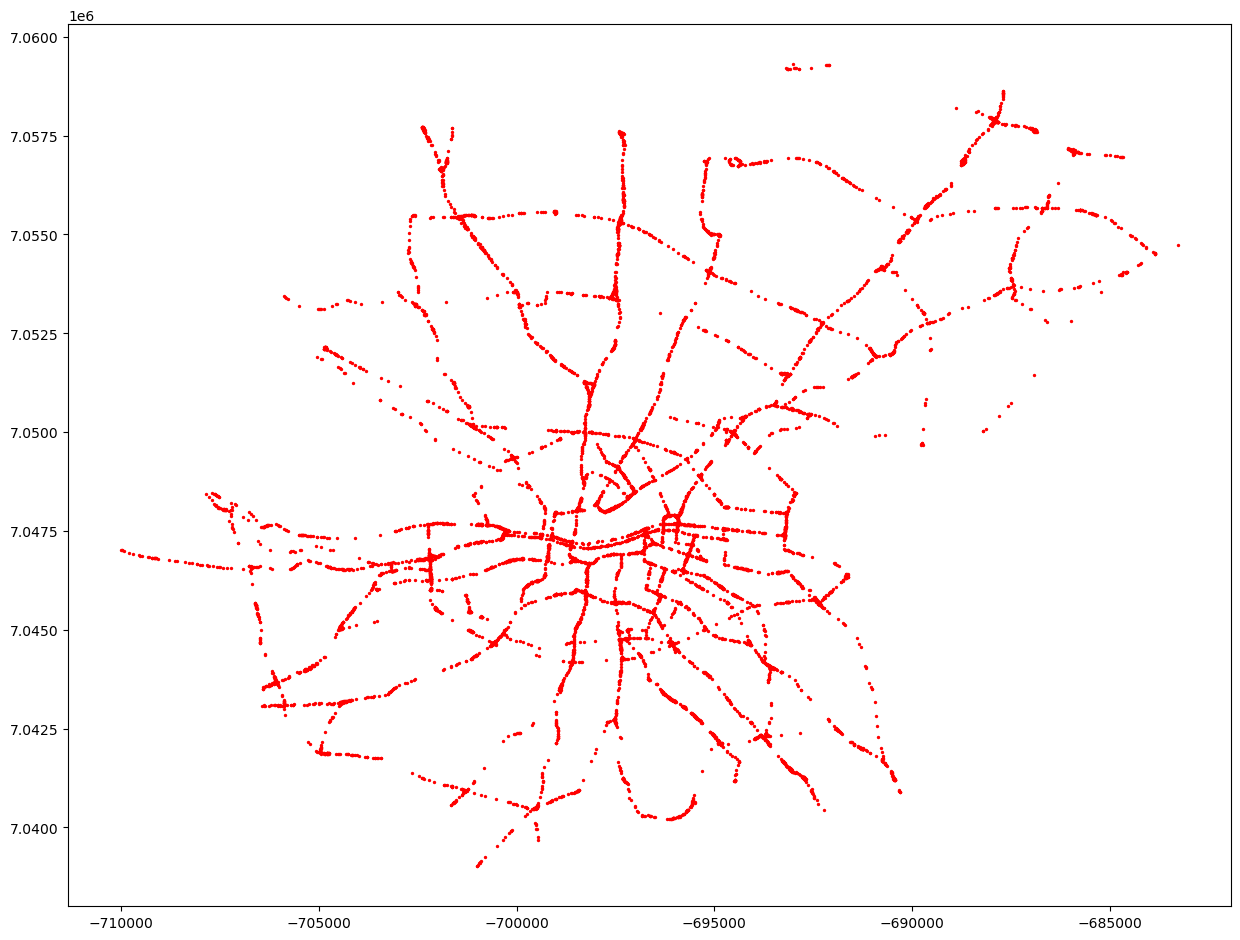

In [36]:
import random
from shapely import LineString

dcc_roads = gpd.read_file("dcc_roads_osm.geojson").to_crs(3857)

num_points = 10000
points = []

while len(points) < num_points:
    random_road = dcc_roads['geometry'].sample(1).offset_curve(random.uniform(-5, 5))
    sampled_point = random_road.interpolate(random.uniform(-random_road.length, random_road.length), normalized=False).reset_index(drop=True)
    points.append(sampled_point.geometry[0])

points_gdf = gpd.GeoDataFrame(geometry=gpd.GeoSeries(points))
fig, ax = plt.subplots(1,1, figsize=(15,12))

#dcc_roads.plot(ax=ax, color='green')
points_gdf.plot(ax=ax, color='red', markersize=2)
plt.show()

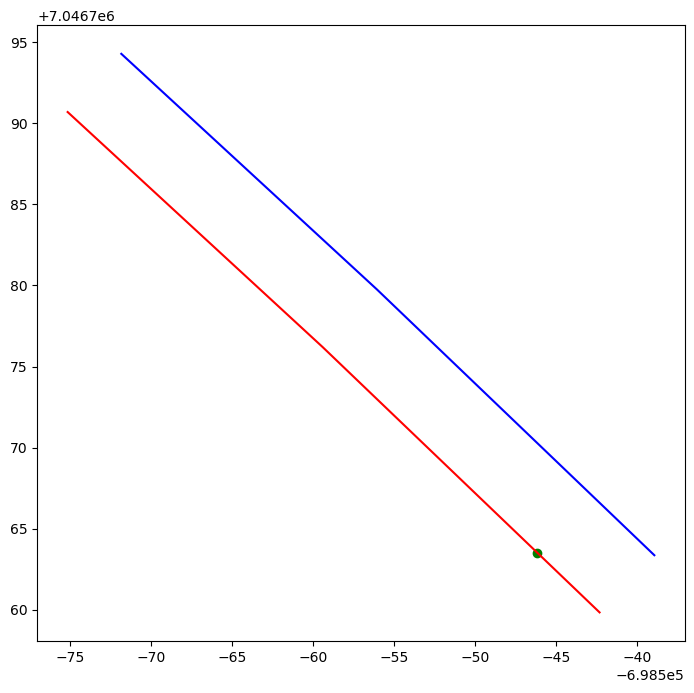

In [35]:
random_road = dcc_roads['geometry'].sample(1)
random_road_offset = random_road.offset_curve(random.uniform(-5, 5))
offset_sample = random_road_offset.interpolate(random.uniform(-random_road_offset.length, random_road_offset.length)).reset_index(drop=True)

fig, ax = plt.subplots(1,1, figsize=(10,8))
random_road.plot(ax=ax, color='blue')
random_road_offset.plot(ax=ax, color='red')
offset_sample.plot(ax=ax, color='green')
plt.show()